# Analyze example

This notebook just loads the response files from LLMs and inspects what they look like and how the models performed

In [4]:
import json
import re
import pandas as pd
from foodscraper.config import *
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-pastel')

In [5]:
responses_path = DATA_DIR / "runs" / "2026-09-16" / "verified_responses"

In [6]:
response_files = sorted(responses_path.glob("*.csv"))
df = pd.concat((pd.read_csv(f) for f in response_files), ignore_index=True)

cols_to_keep = ['model', 'restaurant_id', 'manualVerification']
df = df.loc[:, cols_to_keep]
df

,model,restaurant_id,manualVerification
0,anthropic/claude-sonnet-5,ChIJRzRI2vNTUkYRRndb0XtBWow,incorrect
1,anthropic/claude-sonnet-5,ChIJq9PWX55TUkYRBGa7u0DJYvE,correct
2,anthropic/claude-sonnet-5,ChIJn4ah93RTUkYRzi8qRSKEaAI,correct
3,anthropic/claude-sonnet-5,ChIJr-oJ-HRTUkYRf4fbGF1hGR4,correct
4,anthropic/claude-sonnet-5,ChIJcR5brHVTUkYR80HGten90uY,correct
...,...,...,...
95,openai/gpt-5.6-terra,ChIJJ9NHpQ5TUkYRAhSfTMxPyaw,correct
96,openai/gpt-5.6-terra,ChIJVxNpBJ5TUkYRoUApGaP7jlg,correct
97,openai/gpt-5.6-terra,ChIJC9k8oJ5TUkYRUpX_np_3i8I,correct
98,openai/gpt-5.6-terra,ChIJ6wYguKFTUkYRPiLMpWs4jsc,incorrect


In [7]:
df_grouped = pd.crosstab(df['model'], df['manualVerification'], normalize='index')
df_grouped


manualVerification,correct,incorrect,suboptimal
model,,,
anthropic/claude-sonnet-5,0.7,0.20,0.10
google-ai-studio/gemini-3.7-flash,0.7,0.30,0.00
google-ai-studio/gemini-3.8-flash,0.7,0.25,0.05
openai/gpt-5.6-luna,0.6,0.20,0.20
openai/gpt-5.6-terra,0.8,0.10,0.10


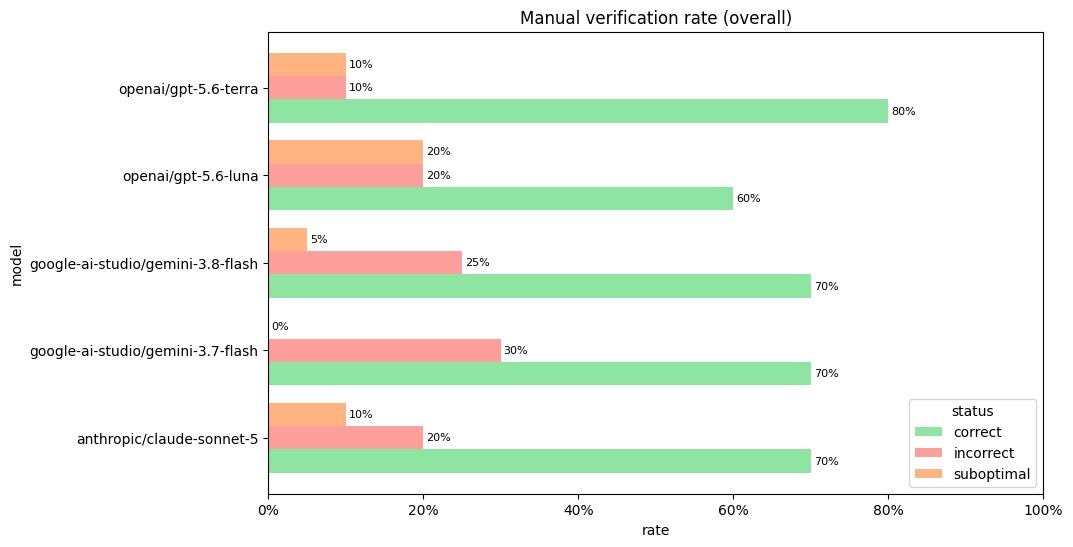

In [8]:
from matplotlib.ticker import PercentFormatter

y = np.arange(len(df_grouped.index))
n_bars = len(df_grouped.columns)
bar_width = 0.8 / n_bars

pal = sns.color_palette('pastel')
colors = {"correct": pal[2], "incorrect": pal[3], "suboptimal": pal[1]}

fig, ax = plt.subplots(figsize=(10, 6))

for i, status in enumerate(df_grouped):
    offset = (i - (n_bars - 1) / 2) * bar_width
    bars = ax.barh(
        y + offset, df_grouped[status], bar_width,
        label=status, color=colors[f"{status}"],
    )
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in df_grouped[status]], padding=2, fontsize=8)

ax.set_xlabel("rate")
ax.set_ylabel("model")
ax.set_title("Manual verification rate (overall)")
ax.set_yticks(y)
ax.set_yticklabels(df_grouped.index)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(title="status")
plt.show()

## Where models disagree

For each restaurant, compare every model's `manualVerification` result side by side and pull out the restaurants where models didn't agree.

In [9]:
df_full = pd.concat((pd.read_csv(f) for f in response_files), ignore_index=True)
df_full['name'] = df_full['input'].apply(lambda x: json.loads(x)['name'])
df_full['hasFoundMenu'] = df_full['answer'].apply(lambda x: json.loads(x)['hasFoundMenu'])
df_full['menuLink'] = df_full['answer'].apply(lambda x: json.loads(x).get('menuLink', ''))

verification_pivot = df_full.pivot(index=['restaurant_id', 'name'], columns='model', values='manualVerification')
disagreements = verification_pivot[verification_pivot.nunique(axis=1) > 1]

print(f"{len(disagreements)} of {len(verification_pivot)} restaurants have disagreeing models")
disagreements

12 of 20 restaurants have disagreeing models


,model,anthropic/claude-sonnet-5,google-ai-studio/gemini-3.7-flash,google-ai-studio/gemini-3.8-flash,openai/gpt-5.6-luna,openai/gpt-5.6-terra
restaurant_id,name,,,,,
ChIJ6wYguKFTUkYRPiLMpWs4jsc,Grimal,incorrect,incorrect,incorrect,correct,incorrect
ChIJFcnV_GNTUkYR9gKbI5rINJM,Mezze,correct,incorrect,correct,correct,correct
ChIJJ9NHpQ5TUkYRAhSfTMxPyaw,Grillaz,correct,correct,suboptimal,correct,correct
ChIJRzRI2vNTUkYRRndb0XtBWow,Berlin Döner,incorrect,incorrect,incorrect,suboptimal,suboptimal
ChIJVxNpBJ5TUkYRoUApGaP7jlg,Café Patina,incorrect,correct,correct,incorrect,correct
ChIJd4d7unVTUkYR_1ErNvKNvYA,La Foretta,suboptimal,correct,correct,suboptimal,suboptimal
ChIJgTOK1Z1TUkYR6zeCXpFaE04,Pasha Kebab,incorrect,incorrect,incorrect,incorrect,correct
ChIJgUgIXCJTUkYROUvU9Ogpqmk,GAO Dumpling Bar,suboptimal,incorrect,incorrect,suboptimal,correct
ChIJk5HSlzNTUkYRVuHEAOh6I4s,La Neta Vesterbro,correct,correct,correct,suboptimal,correct


In [10]:
link_pivot = df_full.pivot(index=['restaurant_id', 'name'], columns='model', values='menuLink')
link_pivot.loc[disagreements.index]

,model,anthropic/claude-sonnet-5,google-ai-studio/gemini-3.7-flash,google-ai-studio/gemini-3.8-flash,openai/gpt-5.6-luna,openai/gpt-5.6-terra
restaurant_id,name,,,,,
ChIJ6wYguKFTUkYRPiLMpWs4jsc,Grimal,https://www.tipster.io/team/32359.html,https://grimal.dk/menu,https://grimal.dk/,https://grimal.dk/madogdrikke/menu,https://grimalw.dk/madogdrikke/menu
ChIJFcnV_GNTUkYR9gKbI5rINJM,Mezze,https://wolt.com/da/dnk/copenhagen/restaurant/...,,https://wolt.com/da/dnk/copenhagen/restaurant/...,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://wolt.com/en/dnk/copenhagen/restaurant/...
ChIJJ9NHpQ5TUkYRAhSfTMxPyaw,Grillaz,https://grillazcph.dk/,https://grillazcph.dk/,https://wolt.com/da/dnk/copenhagen/restaurant/...,https://grillazcph.dk/,https://grillazcph.dk/
ChIJRzRI2vNTUkYRRndb0XtBWow,Berlin Döner,,http://berlindoner.dk/,http://berlindoner.dk/,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://wolt.com/en/dnk/copenhagen/restaurant/...
ChIJVxNpBJ5TUkYRoUApGaP7jlg,Café Patina,https://cafepatina.dk/en/,https://cafepatina.dk/menu/,http://www.cafepatina.dk/menu/,https://cafepatina.dk/,https://cafepatina.dk/en/menu-2/
ChIJd4d7unVTUkYR_1ErNvKNvYA,La Foretta,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://laforetta.bestilonline.dk/,https://laforetta.bestilonline.dk/,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://wolt.com/da/dnk/copenhagen/restaurant/...
ChIJgTOK1Z1TUkYR6zeCXpFaE04,Pasha Kebab,https://pashakebab.dk/menu/,https://pashakebab.dk/,https://pashakebab.dk/menu/,,https://wolt.com/da/dnk/copenhagen/restaurant/...
ChIJgUgIXCJTUkYROUvU9Ogpqmk,GAO Dumpling Bar,https://wolt.com/en/dnk/copenhagen/restaurant/...,http://gaodumpling.com/,http://gaodumpling.com/,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://gaodumpling.com/istedgade
ChIJk5HSlzNTUkYRVuHEAOh6I4s,La Neta Vesterbro,https://www.laneta.dk/menu,https://www.laneta.dk/menu,https://www.laneta.dk/menu,https://wolt.com/en/dnk/copenhagen/restaurant/...,https://www.laneta.dk/menu


In [11]:
df = pd.read_json(GOOGLE_MAPS_DIR / 'copenhagen-10pct-sample.json')

df.head()

,id,name,formattedAddress,websiteUri
0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,"Strandvejen 149, 2900 Hellerup, Denmark",https://platia.dk/pizze-di-napo-hellerup
1,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,"Tempovej 1, 2750 Ballerup, Denmark",https://www.mcdonalds.com/dk/da-dk/location/ba...
2,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,"Nørregade 45c, 1165 København, Denmark",http://byens-pizza.dk/?page_id=2065
3,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,"Slagelsegade 24, 2100 København, Denmark",https://taormina.dk/
4,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,"Blegdamsvej 24, 2200 København, Denmark",http://www.barnetsfest.dk/


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                439 non-null    str  
 1   name              439 non-null    str  
 2   formattedAddress  439 non-null    str  
 3   websiteUri        354 non-null    str  
dtypes: str(4)
memory usage: 62.9 KB
